# Introduction to Linear Regression

In our past blog posts, we have mostly dealt with classification - how do we classify a point as part of one group, or the other. However, in this blog post we are going to be dealing with numerical values - how do we make numerical predictions? This means that given a feature matrix - $X \in \mathbb{R}^{n*p}$ - how do we use those features to make numerical predictions about what the value - $y_i$ - will be! In this blog post, we will be dealing with linear regression. This can be visualized as follows: 

<center><img src = "data.png" width=800 height=500/></center>

Based on the above image, if we were to come up with a prediction of what the output value $y_i$ would be, for each point on the x-axis, $x_i$, how do we do that? In this situation, we are dealing with $1$-feature - so, how do we predict the output based on that one feature? The goal of linear regression is to come up with a line which most closely simulates the pattern of the data points. One could visualize a line like this, for instance: 

<center><img src = "data_line.png" width=800 height=500/></center>
    
In this blog post, we will be looking at two ways to find the ideal parameters to formulate the line which closely follows the pattern of the data:

<ol>
    <li><b>Using an Analytical Formula</b>
    <br> When we explicitly set the gradient $\nabla L(w) = 0$ - condition for minimum! We end up getting the formula, $\hat w = (X^TX)^{-1}X^Ty$ - <a href ="https://middlebury-csci-0451.github.io/CSCI-0451/lecture-notes/regression.html">from Lecture Notes (03/08)</a>. Plugging in all the values, results in an explicit formula that churns out the values for $\hat w$. However, the problem with this approach is that it is computationally very expensive. Hence, we have a second way!
    <br><br><li><b>Using Gradient Descent</b>
    <br> We know that the gradient of the loss function is - $\nabla L(w) = 2X^T(Xw-y)$ - <a href="https://middlebury-csci-0451.github.io/CSCI-0451/lecture-notes/regression.html">from Lecture Notes (03/08)</a>. Therefore, we can run a loop for a maximum number of times - <i>max_iter</i> - and on each iteration we can make the update $w^{(t+1)} \leftarrow w^{(t)} - (\alpha * \text{gradient})$. We could check for convergence to add a <i>break</i> statement. Precomputing some values allows us to make this computation more efficient
</ol>

# Implementation of Linear Regression using Analytical Formula

Creating <b>testing</b> and <b>validation</b> data, to see how our i) Analytical Formula approach, and ii) Gradient Descent approach perform, when we are trying to do linear regression!

In [17]:
import numpy as np
from matplotlib import pyplot as plt 

def pad(X):
    return np.append(X, np.ones((X.shape[0], 1)), 1)

def LR_data(n_train = 100, n_val = 100, p_features = 1, noise = .1, w = None):
    if w is None: 
        w = np.random.rand(p_features + 1) + .2
    
    #creating a random X_train matrix with n_train rows - data points - and p_features columns - the features
    X_train = np.random.rand(n_train, p_features)
    y_train = pad(X_train)@w + noise*np.random.randn(n_train)

    X_val = np.random.rand(n_val, p_features)
    y_val = pad(X_val)@w + noise*np.random.randn(n_val)
    
    return X_train, y_train, X_val, y_val

Generating some data using the above method. We are keeping the number of <i>features</i> = $1$, for visualization purposes:

In [18]:
X_train, y_train, X_val, y_val = LR_data(n_train = 100, n_val = 100, p_features = 1, noise = 0.1)

#creating a padded version of X_train and y_train
X_train_padded = pad(X_train)
X_val_padded = pad(X_val)

Now let us plot this data: 

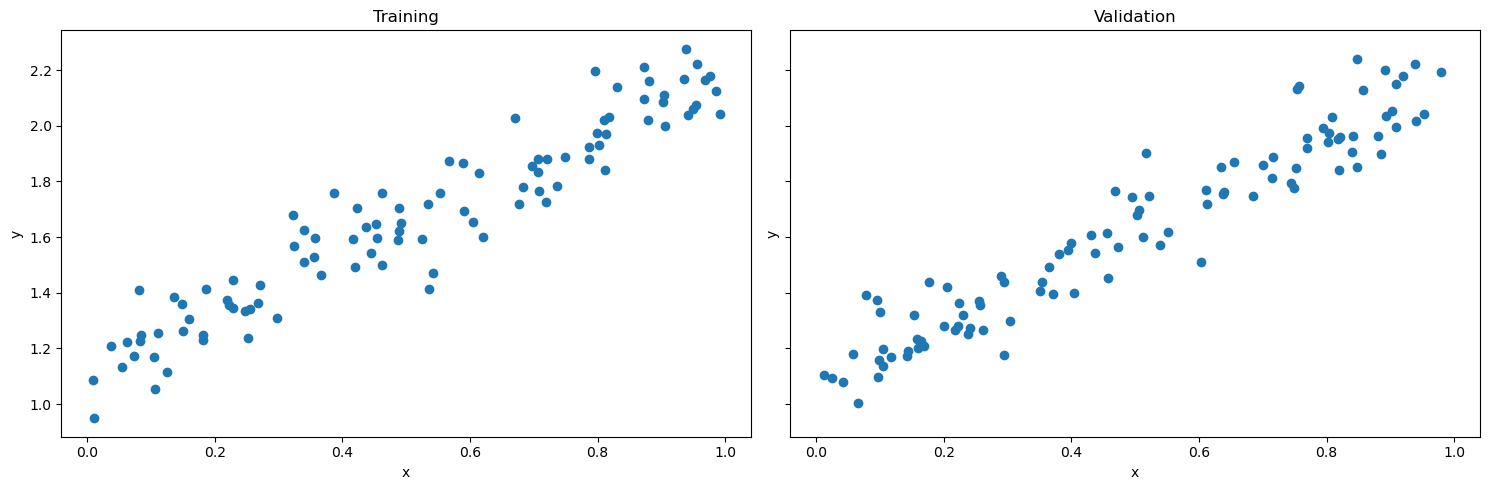

In [19]:
fig, axarr = plt.subplots(1, 2, sharex = True, sharey = True)
plt.rcParams["figure.figsize"] = (15,5)
axarr[0].scatter(X_train, y_train)
axarr[1].scatter(X_val, y_val)
labs = axarr[0].set(title = "Training", xlabel = "x", ylabel = "y")
labs = axarr[1].set(title = "Validation", xlabel = "x", ylabel = "y")
plt.tight_layout()

Using our <b>Linear Regression</b> implementation to see how well it performs on the <i>training data</i> and <i>validation data</i>! We will use both <b>analytical formula method</b>, and the <b>gradient descent method</b>.

In [21]:
from LinearRegression import LinearRegression

#creating an object of the LinearRegression class
LR = LinearRegression()

#using the analytical formula first
LR.fit_analytic(X_train, y_train)

print(f"Training score = {LR.score(X_train_padded, y_train).round(4)}")
print(f"Validation score = {LR.score(X_val_padded, y_val).round(4)}")

Training score = 0.9065
Validation score = 0.9096


Estimated Weight Vector:

In [22]:
LR.w

array([1.06087805, 1.11986841])

We can visualize the line that the weight vector from our analytical formula forms:

# Implementation of Linear Regression using Gradient Descent

In [27]:
LR2 = LinearRegression()
LR2.fit_gradient(X_train, y_train, alpha = 0.0001, max_iter = 100000)

In [28]:
LR2.score_history[-1]

0.9064833666912417